# ch218 — Curvature

Curvature measures how fast a curve turns. A straight line has zero curvature. A tight circle has high curvature. The concept connects second derivatives *(ch217)* to geometry *(Part IV)*.

In optimisation, curvature of the loss landscape determines whether gradient descent *(ch212)* converges quickly or oscillates.

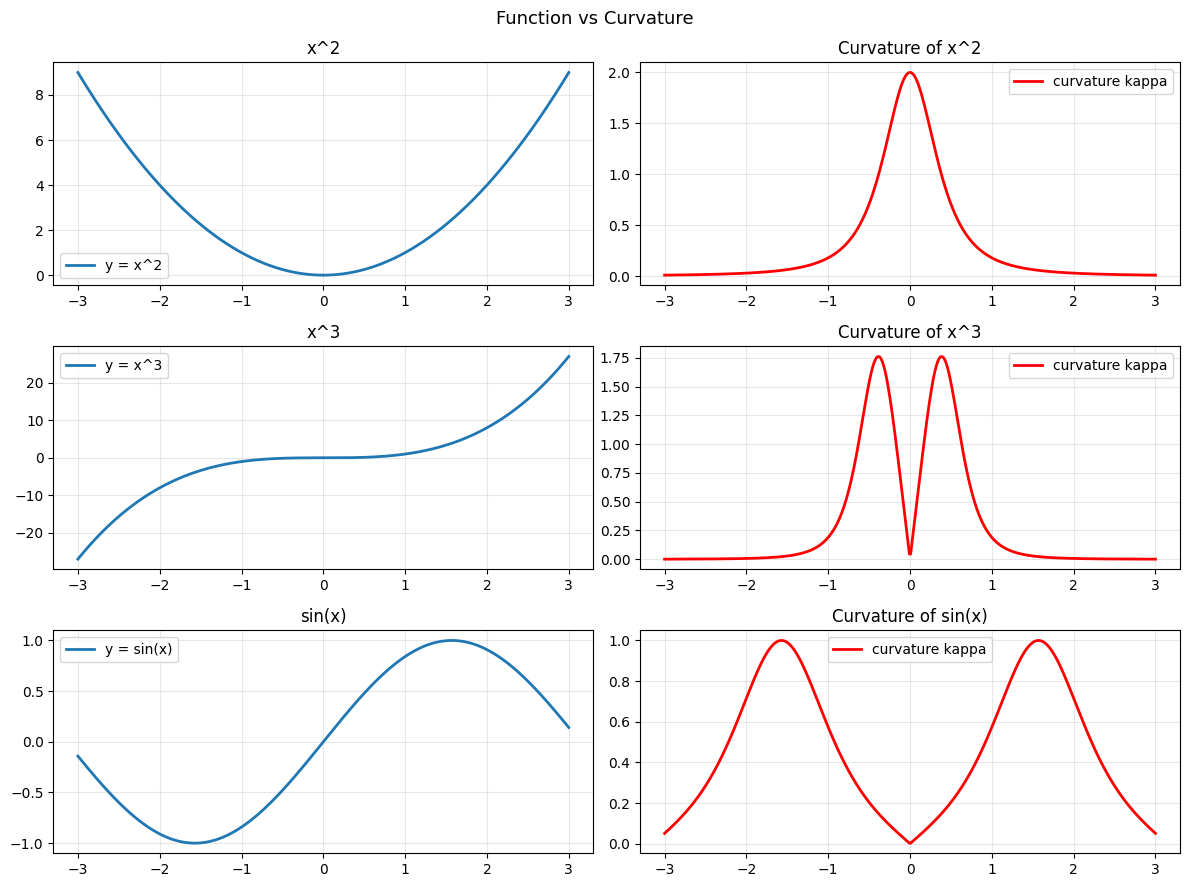

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Curvature of y = f(x):
# kappa = |f''| / (1 + f'^2)^(3/2)

x = np.linspace(-3, 3, 400)

functions = [
    ('x^2',     lambda x: x**2,      lambda x: 2*x,    lambda x: 2*np.ones_like(x)),
    ('x^3',     lambda x: x**3,      lambda x: 3*x**2, lambda x: 6*x),
    ('sin(x)',   lambda x: np.sin(x), lambda x: np.cos(x), lambda x: -np.sin(x)),
]

fig, axes = plt.subplots(len(functions), 2, figsize=(12, 9))
for i, (name, f, f1, f2) in enumerate(functions):
    kappa = np.abs(f2(x)) / (1 + f1(x)**2) ** 1.5
    axes[i, 0].plot(x, f(x), lw=2, label=f'y = {name}')
    axes[i, 0].set_title(f'{name}'); axes[i, 0].legend(); axes[i, 0].grid(True, alpha=0.3)
    axes[i, 1].plot(x, kappa, lw=2, color='red', label='curvature kappa')
    axes[i, 1].set_title(f'Curvature of {name}'); axes[i, 1].legend(); axes[i, 1].grid(True, alpha=0.3)

plt.suptitle('Function vs Curvature', fontsize=13)
plt.tight_layout(); plt.savefig('ch218_curvature.png', dpi=100); plt.show()


## Radius of Curvature

At each point on a curve, we can fit the **osculating circle** — the circle that best approximates the curve at that point. Its radius `R = 1/kappa` is the radius of curvature.

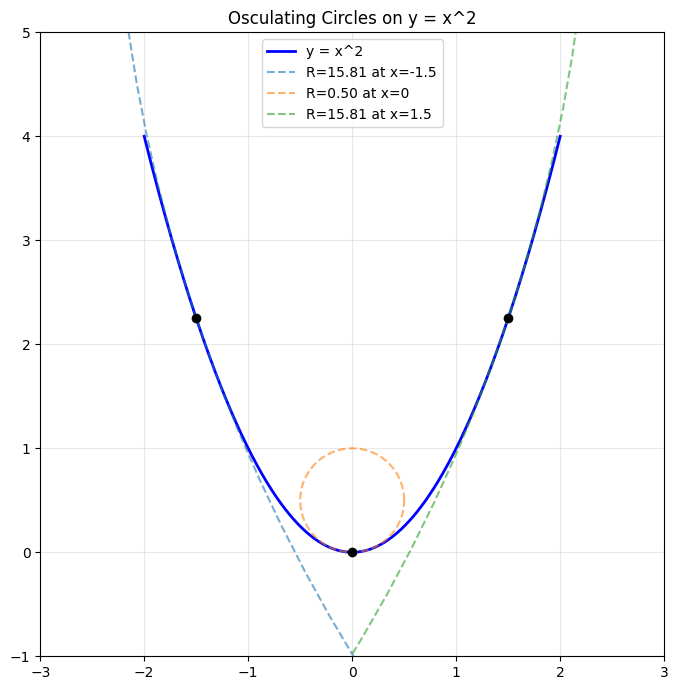

In [2]:
# Osculating circles at different points on y = x^2
fig, ax = plt.subplots(figsize=(8, 7))
x_curve = np.linspace(-2, 2, 400)
ax.plot(x_curve, x_curve**2, 'b', lw=2, label='y = x^2')
ax.set_aspect('equal')

for x0 in [-1.5, 0, 1.5]:
    y0 = x0**2
    f1_at = 2*x0
    f2_at = 2.0
    kappa = abs(f2_at) / (1 + f1_at**2)**1.5
    R = 1.0 / kappa

    # Centre of osculating circle
    cx = x0 - f1_at * (1 + f1_at**2) / f2_at
    cy = y0 + (1 + f1_at**2) / f2_at

    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(cx + R*np.cos(theta), cy + R*np.sin(theta), '--', alpha=0.6, label=f'R={R:.2f} at x={x0}')
    ax.plot(x0, y0, 'ko', ms=6)

ax.legend(loc='upper center'); ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 3); ax.set_ylim(-1, 5)
ax.set_title('Osculating Circles on y = x^2')
plt.tight_layout(); plt.savefig('ch218_osculating.png', dpi=100); plt.show()


## Curvature in Optimisation

High curvature means the gradient changes rapidly — gradient steps that are calibrated for one point will overshoot. Low curvature means slow progress. The **condition number** of the Hessian captures this imbalance across dimensions.

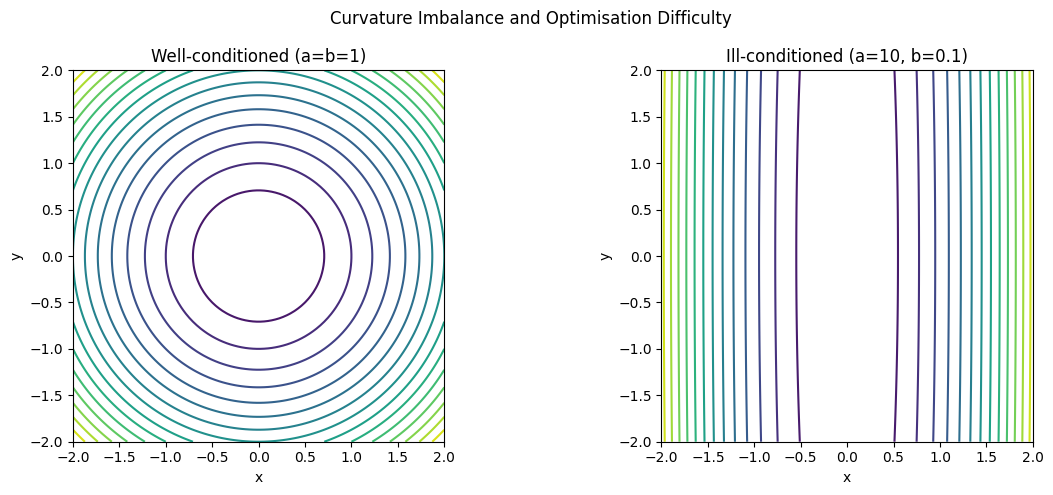

Condition number (a=10, b=0.1): 100.0
Gradient descent struggles when this ratio is large.


In [3]:
# Loss landscape with different curvatures in each direction
# L = a*x^2 + b*y^2  with a >> b => ill-conditioned

x_g = np.linspace(-2, 2, 100)
y_g = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_g, y_g)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (a, b), title in zip(axes,
        [(1, 1), (10, 0.1)],
        ['Well-conditioned (a=b=1)', 'Ill-conditioned (a=10, b=0.1)']):
    Z = a * X**2 + b * Y**2
    ax.contour(X, Y, Z, levels=15, cmap='viridis')
    ax.set_aspect('equal'); ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Curvature Imbalance and Optimisation Difficulty')
plt.tight_layout(); plt.savefig('ch218_conditioning.png', dpi=100); plt.show()
print("Condition number (a=10, b=0.1):", 10 / 0.1)
print("Gradient descent struggles when this ratio is large.")


## Summary

| Concept | Formula / Meaning |
|---|---|
| Curvature | kappa = |f''| / (1+f'^2)^(3/2) |
| Radius of curvature | R = 1/kappa |
| Osculating circle | Circle with radius R tangent to curve |
| Condition number | max eigenvalue / min eigenvalue of Hessian |

**Forward reference:** ch219 — Taylor Series uses curvature (the second-order term) to approximate functions near a point.